In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

In [25]:
DATA_PATH = "data/UNSW_NB15_training-set.csv"
FEATURES_PATH = "data/NUSW-NB15_features.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1")
features = pd.read_csv(FEATURES_PATH, encoding="latin1")

print("Shape:", df.shape)
df.head()

Shape: (175341, 45)


,ï»¿id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ï»¿id              175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [27]:
print("Label distribution:")
print(df["label"].value_counts())

print("\nAttack category distribution:")
print(df["attack_cat"].value_counts())

Label distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Attack category distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [28]:
attack_counts = df["attack_cat"].value_counts().reset_index()
attack_counts.columns = ["attack_cat", "count"]
attack_counts["percent"] = attack_counts["count"] / attack_counts["count"].sum() * 100

attack_counts

,attack_cat,count,percent
0,Normal,56000,31.937767
1,Generic,40000,22.812691
2,Exploits,33393,19.044605
3,Fuzzers,18184,10.370649
4,DoS,12264,6.994371
5,Reconnaissance,10491,5.983198
6,Analysis,2000,1.140635
7,Backdoor,1746,0.995774
8,Shellcode,1133,0.646169
9,Worms,130,0.074141


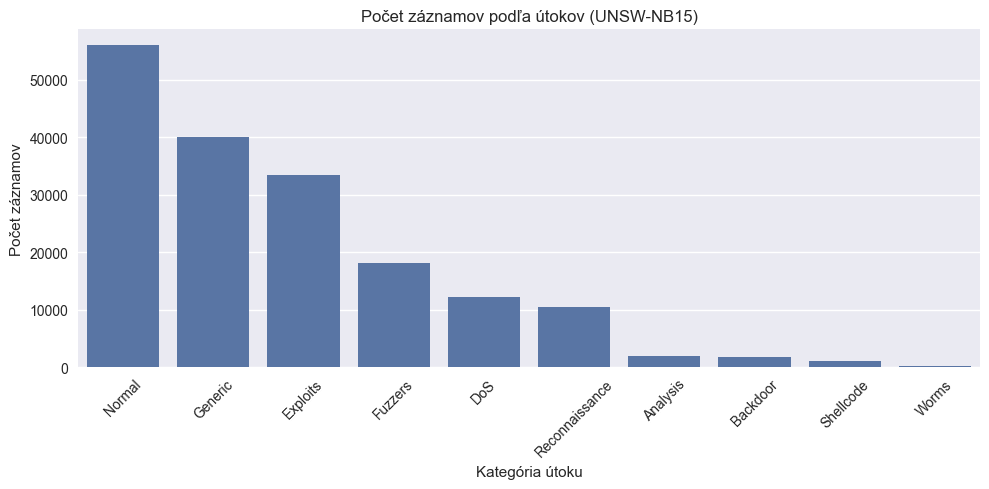

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(data=attack_counts, x="attack_cat", y="count")
plt.xticks(rotation=45)
plt.title("Počet záznamov podľa útokov (UNSW-NB15)")
plt.xlabel("Kategória útoku")
plt.ylabel("Počet záznamov")
plt.tight_layout()
plt.show()

In [30]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Počet numerických atribútov:", len(numeric_cols))
numeric_cols

Počet numerických atribútov: 41


['ï»¿id',
 'dur',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_srv_src',
 'ct_state_ttl',
 'ct_dst_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'ct_src_ltm',
 'ct_srv_dst',
 'is_sm_ips_ports',
 'label']

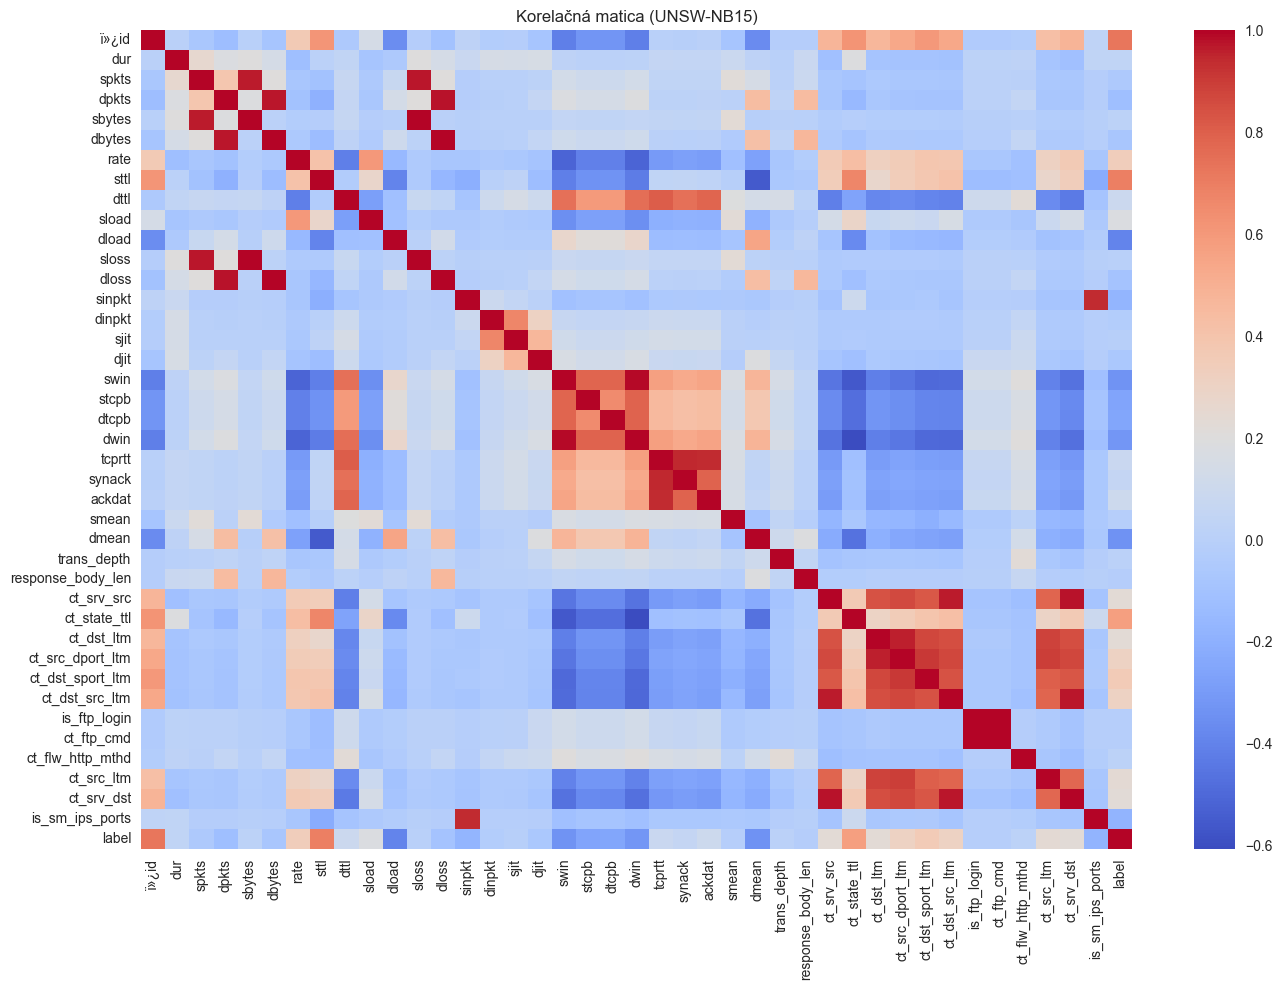

In [31]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Korelačná matica (UNSW-NB15)")
plt.tight_layout()
plt.show()

In [32]:
attack_mapping = df.groupby("attack_cat")

datasets = {}
for attack, group in attack_mapping:
    datasets[attack] = group
    print(f"{attack}: {group.shape}")

Analysis: (2000, 45)
Backdoor: (1746, 45)
DoS: (12264, 45)
Exploits: (33393, 45)
Fuzzers: (18184, 45)
Generic: (40000, 45)
Normal: (56000, 45)
Reconnaissance: (10491, 45)
Shellcode: (1133, 45)
Worms: (130, 45)


In [33]:
os.makedirs("data/attacks", exist_ok=True)

for name, subset in datasets.items():
    filename = f"data/attacks/{name}.csv"
    subset.to_csv(filename, index=False)

print("Datasety uložené do data/attacks/")

Datasety uložené do data/attacks/


In [34]:
print("Features file shape:", features.shape)
features.head()

Features file shape: (49, 4)


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
